# Домашнее задание

В этом домашнем задании вы обучите полносвязную нейронную сеть для решения задачи классификации на датасете CIFAR-10. В этом датасете содержатся цветные (трехканальные) изображения размера 32 на 32 пикселя. Изображения относятся к 10 классам.

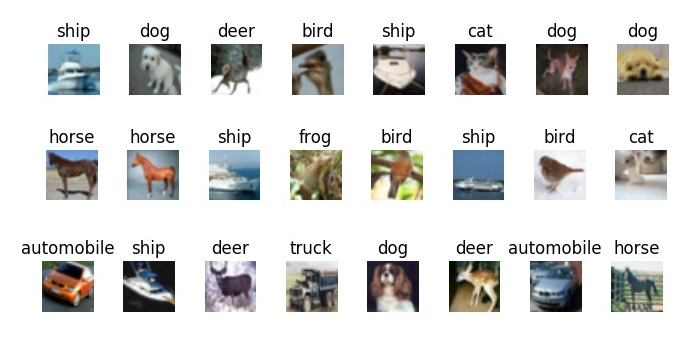

In [1]:
%pip install torch torchvision

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import random
import numpy as np

np.random.seed(0)
random.seed(0)
torch.manual_seed(0)

## Задание

Задайте гиперпаметры для нейронной сети:

* `input_size` - число входных признаков (равно число пикселей * число каналов). Вычислите `input_size` самостоятельно.

* `hidden_size` - число нейронов на скрытом слое сети. Поставьте 500.

* `num_classes` - число классов. Задайте самостоятельно.

Чему равен `input_size`? (3072)


In [3]:
# Check Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define Hyper-parameters
input_size = 3072
hidden_size = 500
num_classes = 10
num_epochs = 10
batch_size = 100
learning_rate = 0.001

Загрузим данные и масштабируем их.

In [4]:
# CIFAR dataset
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_dataset = torchvision.datasets.CIFAR10(root='../../data',
                                           train=True,
                                           transform=transform,
                                           download=True)

test_dataset = torchvision.datasets.CIFAR10(root='../../data',
                                          train=False,
                                          transform=transform)

## Задание

Сколько объектов в `train_dataset`? (50000)

Создадим data-loaders.

In [5]:
# Data loader
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=batch_size,
                                          shuffle=False)

## Задание

Допишите метод `forward`. Архитектура сети следующая:

1) Полносвязный слой `fc1`

2) Функция активации ReLU

3) Полносвязный слой `fc2`

Сколько нейронов поступает на вход (`in_features`) в слой `fc2`? (500)

In [6]:
# Fully connected neural network
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)     
        x = self.relu(self.fc1(x))     
        x = self.fc2(x)                
        return x


model = NeuralNet(input_size, hidden_size, num_classes).to(device)

Задайте Loss - кросс-энтропию и оптимизатор - Adam с learning_rate, определенным константой из первого задания.

In [7]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## Задание

Допишите цикл для обучения модели:

1) На вход в цикле подается объект `images` - батч, состоящий из картинок, вытянутых в вектор. Объект `images` переносится на device (на видеокарту, если есть).

2) Каждую сотую итерацию добавляйте значение функции потерь в список log_loss. Значние функции потерь можно посмотреть в `loss.data` (не забудьте перевести tensor в np.array при помощи метода `.numpy()`, а если делаете вычисления на gpu, то `.cpu().numpy()`)

Чему равен loss на последней итерации после отработки цикла? Ответ округлите до целого числа.(1)

In [8]:
import torch.nn.functional as F
np.random.seed(0)
random.seed(0)
torch.manual_seed(0)

loss_log = []

# Train the model
total_step = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        # Move tensors to the configured device
        images = images.to(device)  
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backprpagation and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1) % 100 == 0:
            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'
                   .format(epoch+1, num_epochs, i+1, total_step, loss.item()))
            loss_log.append(loss.data.numpy())

Epoch [1/10], Step [100/500], Loss: 1.7296
Epoch [1/10], Step [200/500], Loss: 1.3784
Epoch [1/10], Step [300/500], Loss: 1.7142
Epoch [1/10], Step [400/500], Loss: 1.5322
Epoch [1/10], Step [500/500], Loss: 1.5169
Epoch [2/10], Step [100/500], Loss: 1.7152
Epoch [2/10], Step [200/500], Loss: 1.4953
Epoch [2/10], Step [300/500], Loss: 1.6736
Epoch [2/10], Step [400/500], Loss: 1.3012
Epoch [2/10], Step [500/500], Loss: 1.5095
Epoch [3/10], Step [100/500], Loss: 1.2693
Epoch [3/10], Step [200/500], Loss: 1.5726
Epoch [3/10], Step [300/500], Loss: 1.1788
Epoch [3/10], Step [400/500], Loss: 1.2349
Epoch [3/10], Step [500/500], Loss: 1.4394
Epoch [4/10], Step [100/500], Loss: 1.0662
Epoch [4/10], Step [200/500], Loss: 1.1301
Epoch [4/10], Step [300/500], Loss: 1.1655
Epoch [4/10], Step [400/500], Loss: 1.2376
Epoch [4/10], Step [500/500], Loss: 1.3943
Epoch [5/10], Step [100/500], Loss: 1.1356
Epoch [5/10], Step [200/500], Loss: 1.1560
Epoch [5/10], Step [300/500], Loss: 0.9992
Epoch [5/10

## Задание  

Нарисуйте график изменения лосса, используя список `loss_log`.

Что можно сказать по этому графику?

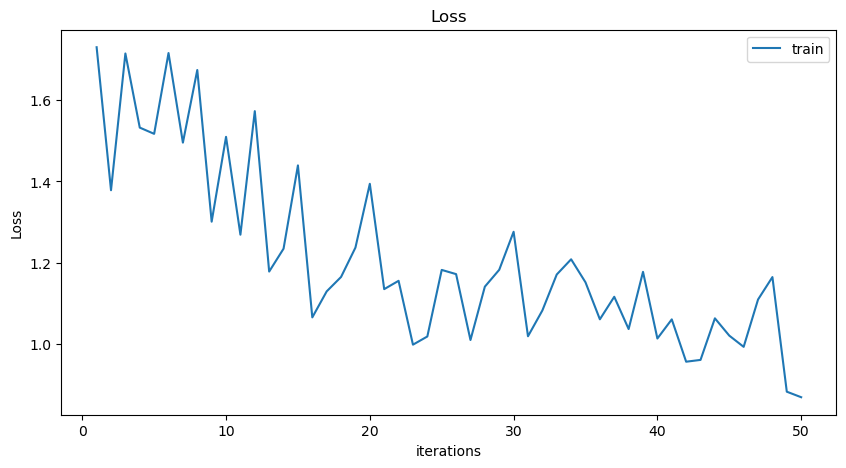

In [9]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10,5))
plt.title("Loss")
plt.plot(np.arange(1,len(loss_log)+1), loss_log, label="train")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Задание

Допишите цикл тестирования модели:

1) На вход, как и в предыдущем задании, подайте такой же тензор `images` и перенесите его на device

2) Также задайте `labels`

3) Сделайте прогноз модели на мини-батче `images` - результат будет в `outputs`

4) В конце вычислите `accuracy` и выведите ее на экран по формуле $100 \cdot correct / total$

Чему равна `accuracy`? Ответ округлите до целого числа.(52)

In [10]:
np.random.seed(0)
random.seed(0)
torch.manual_seed(0)

# Test the model
# In the test phase, don't need to compute gradients (for memory efficiency)
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)     
        labels = labels.to(device)      

        outputs = model(images)  
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # your code for accuracy here

    accuracy = 100 * correct / total    
    print(f'Accuracy: {accuracy:.2f}%')
# Save the model checkpoint
torch.save(model.state_dict(), 'model.ckpt')

Accuracy: 51.65%


## Задание

Создайте нейронную сеть со сверточными слоями.

Выполните обучение вашей сверточной нейронной сети на том же датасете CIFAR-10.

Нарисуйте график именения `loss`'a в процессе обучения.

Протестируйте созданную модель на небольшом батче, вычислив метрику `accuracy`.

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Фиксируем seed
np.random.seed(0)
torch.manual_seed(0)

input_size = 3072
hidden_size = 500
num_classes = 10
num_epochs = 10
batch_size = 100
learning_rate = 0.001

# Устройство
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_dataset = torchvision.datasets.CIFAR10(root='../../data',
                                           train=True,
                                           transform=transform,
                                           download=True)

test_dataset = torchvision.datasets.CIFAR10(root='../../data',
                                          train=False,
                                          transform=transform)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True)

test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                          batch_size=batch_size,
                                          shuffle=False)

In [15]:
# Простая сверточная сеть
class SimpleConvNet(nn.Module):
    def __init__(self, num_classes):
        super(SimpleConvNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleConvNet(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [16]:
loss_log = []

total_step = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        # Move tensors to the configured device
        images = images.to(device)  
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backprpagation and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i+1) % 100 == 0:
            print ('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}'
                   .format(epoch+1, num_epochs, i+1, total_step, loss.item()))
            loss_log.append(loss.data.numpy())

Epoch [1/10], Step [100/500], Loss: 1.7071
Epoch [1/10], Step [200/500], Loss: 1.3051
Epoch [1/10], Step [300/500], Loss: 1.1827
Epoch [1/10], Step [400/500], Loss: 1.2677
Epoch [1/10], Step [500/500], Loss: 1.1341
Epoch [2/10], Step [100/500], Loss: 0.9466
Epoch [2/10], Step [200/500], Loss: 1.0932
Epoch [2/10], Step [300/500], Loss: 1.0517
Epoch [2/10], Step [400/500], Loss: 1.0077
Epoch [2/10], Step [500/500], Loss: 1.1428
Epoch [3/10], Step [100/500], Loss: 0.8402
Epoch [3/10], Step [200/500], Loss: 0.9244
Epoch [3/10], Step [300/500], Loss: 0.8462
Epoch [3/10], Step [400/500], Loss: 0.8194
Epoch [3/10], Step [500/500], Loss: 0.8010
Epoch [4/10], Step [100/500], Loss: 0.8328
Epoch [4/10], Step [200/500], Loss: 1.0850
Epoch [4/10], Step [300/500], Loss: 0.7085
Epoch [4/10], Step [400/500], Loss: 0.7224
Epoch [4/10], Step [500/500], Loss: 0.7660
Epoch [5/10], Step [100/500], Loss: 0.7037
Epoch [5/10], Step [200/500], Loss: 0.5680
Epoch [5/10], Step [300/500], Loss: 0.6849
Epoch [5/10

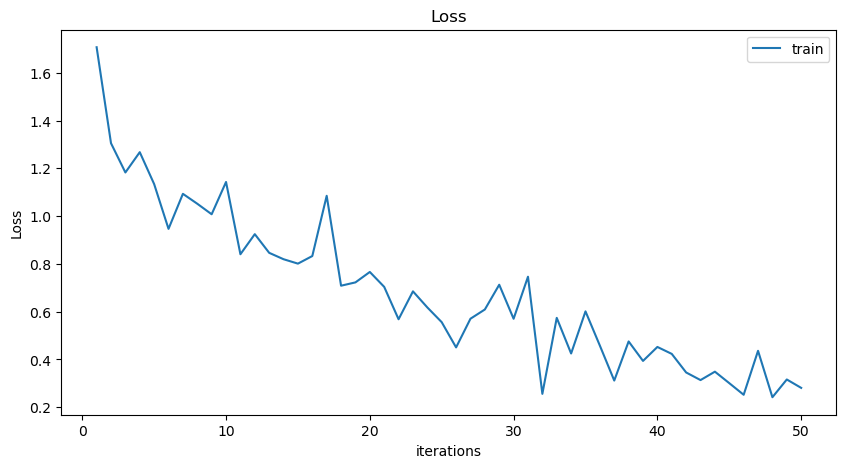

In [17]:
plt.figure(figsize=(10,5))
plt.title("Loss")
plt.plot(np.arange(1,len(loss_log)+1), loss_log, label="train")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [18]:
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)     
        labels = labels.to(device)      

        outputs = model(images)  
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total    
    print(f'Accuracy: {accuracy:.2f}%')
# Save the model checkpoint
torch.save(model.state_dict(), 'model.ckpt')

Accuracy: 72.72%
